# The Mechanistic Anchor.
## 2. The "White Box"
## ⚙️ The Paradigm: Deterministic Mass Balances
In mechanistic modeling, we do not guess the shape of the manifold using polynomials. Instead, we calculate the exact trajectory of the system over time using the universal law of conservation of mass:

Accumulation = (Input - Output) + (Generation - Consumption)

In a simple closed batch bioreactor (no feeding, no bleeding), Input and Output are zero. The entire 14-day process is dictated simply by how fast the CHO cells generate biomass and mAbs, and how fast they consume glucose.
To model this, we use a system of coupled ODEs. An ODE simply describes a "Rate of Change" over time ($\frac{d}{dt}$). We need three fundamental equations: one for the Cells ($X$), one for the Substrate/Glucose ($S$), and one for the Product/mAb ($P$).

## 🦠 1. Cell Growth: The Monod Equation
How fast do CHO cells divide? You know that if they have plenty of glucose, they divide at their maximum biological limit. As glucose runs out, they starve and slow down.
In 1942, Jacques Monod realized this behaves exactly like enzyme kinetics (Michaelis-Menten). He created the Monod Equation to calculate the "Specific Growth Rate" ($\mu$):$$\mu = \mu_{max} \frac{S}{K_s + S}$$
- $\mu$ (mu): The current growth rate ($h^{-1}$).
- $\mu_{max}$: The absolute maximum growth rate of your specific CHO clone when food is unlimited.
- $S$: The current Substrate (glucose) concentration in the bioreactor (g/L).
- $K_s$: The half-saturation constant. This is the exact glucose concentration where the cells grow at exactly half of $\mu_{max}$. It represents the cell's "affinity" for the nutrient.
The Cell Growth ODE:
To find out how the total cell mass ($X$) changes over time, we multiply the specific growth rate by the current number of cells:$$\frac{dX}{dt} = \mu X$$(Read as: The change in cell mass over time equals the current growth rate times the current amount of cells).

## 🍔 2. Substrate Consumption: 
The Yield CoefficientAs the cells grow, they eat. The rate at which glucose disappears is directly tied to the rate at which cells appear. We link these two ODEs using a biological conversion factor called the Yield Coefficient ($Y_{X/S}$).$Y_{X/S}$ tells you: "How many grams of Cells ($X$) are produced for every gram of Substrate ($S$) consumed?"The Substrate ODE:$$\frac{dS}{dt} = -\frac{1}{Y_{X/S}} \mu X$$(Read as: The change in glucose over time is the negative growth rate of the cells, scaled by how efficiently they convert food into mass).

## 💉 3. mAb Production: The Luedeking-Piret Equation
Here is the most critical equation for the biotechnology industry. How do we model the secretion of the monoclonal antibody ($P$)?In 1959, Luedeking and Piret discovered that biological product formation happens in two distinct ways:
1. Growth-Associated ($\alpha$): The cell makes the product while it is dividing (like building structural cell membrane proteins).
2. Non-Growth-Associated ($\beta$): The cell makes the product while it is resting/stationary (like secreting secondary metabolites or antibodies when the cell is fully mature but no longer dividing).
The Product ODE:$$\frac{dP}{dt} = \alpha \frac{dX}{dt} + \beta X$$Substituting $\frac{dX}{dt}$ with $\mu X$, we get the classic form:$$\frac{dP}{dt} = \alpha \mu X + \beta X$$The Biological Reality for mAbs:As a biologist, you know that CHO cells produce the vast majority of their IgG titers during the stationary phase (Days 7-14), when growth ($\mu$) has basically stopped. Therefore, in mAb bioprocessing, the $\alpha$ term is usually very small, and the $\beta$ term (the factory running at steady-state) is the primary driver of your titer!
## 🧠 The Mental Model: How They Couple Together
Unlike the machine learning models from Chapter 2 where inputs and outputs are just static columns in a spreadsheet, mechanistic ODEs are intimately "coupled" and dynamic:
- Glucose ($S$) dictates the growth rate ($\mu$).
- The growth rate ($\mu$) creates more Cells ($X$).
- More Cells ($X$) drain the Glucose ($S$) faster.
- The combination of growing and resting Cells ($X$) secretes the mAb ($P$).

If you start a simulation at $t=0$ with 0.1 g/L of Cells and 5.0 g/L of Glucose, the math will cascade forward, minute by minute, generating the classic S-shaped growth curve, the declining glucose curve, and the rising titer curve, all based purely on physical kinetics. No polynomials required!
## 💻 Exercise 3: Coding the Biological Laws

In [1]:
# Calling dependencies
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

In [2]:
# ==========================================
# 1. DEFINE THE BIOLOGICAL LAWS (The ODEs)
# ==========================================

def bioreactor_batch(y, t, mu_max, Ks, Y_xs, alpha, beta):
    """
    This function holds the physics of our CHO cell.
    y: A list containing the current values of [Cells, Glucose, mAb]
    t: The current time (days)
    """
    # Unpack the current state
    X, S, P = y
    
    # BIOLOGICAL LIMIT: Cells cannot eat negative glucose
    # If glucose hits 0, growth stops.
    if S <= 0:
        S = 0
        mu = 0
    else:
        # The Monod Equation (Current Growth Rate)
        mu = mu_max * (S / (Ks + S))
        
    # 1. Cell Growth Rate (dX/dt)
    dXdt = mu * X

    # 2. Glucose Consumption Rate (dS/dt)
    dSdt = -(1 / Y_xs) * dXdt

    # 3. mAb Production Rate (dP/dt) - Luedeking-Piret
    dPdt = alpha * dXdt + beta * X

    # Return the calculated rates of change
    return [dXdt, dSdt, dPdt]

In [3]:
# ==========================================
# 2. SET THE CLONE-SPECIFIC KINETIC PARAMETERS
# ==========================================
mu_max = 0.8    # Max growth rate (1/day)
Ks = 0.5        # Monod affinity constant (g/L) - low means it scavenges well
Y_xs = 0.4      # Yield: 0.4 grams of Cells produced per 1 gram Glucose eaten
alpha = 0.05    # Growth-associated mAb production (g_mAb / g_Cells)
beta = 0.1      # Non-growth-associated mAb production (g_mAb / g_Cells / day)

parameters = (mu_max, Ks, Y_xs, alpha, beta)

In [4]:
# ==========================================
# 3. SET THE INITIAL CONDITIONS (Day 0)
# ==========================================
X0 = 0.1  # Inoculum: Starting cell mass (g/L)
S0 = 10.0 # Starting Glucose (g/L)
P0 = 0.0  # Starting mAb titer (g/L)
y0 = [X0, S0, P0]

# Create a time vector from Day 0 to Day 14 (100 smooth steps)
time_days = np.linspace(0, 14, 100)

In [5]:
# ==========================================
# 4. RUN THE SIMULATION (Solve the ODEs)
# ==========================================
# odeint steps through 'time_days', repeatedly calling 'bioreactor_batch'
solution = odeint(bioreactor_batch, y0, time_days, args=parameters)

# Unpack the results
X_sim = solution[:, 0] # Biomass over time
S_sim = solution[:, 1] # Glucose over time
P_sim = solution[:, 2] # mAb Titer over time

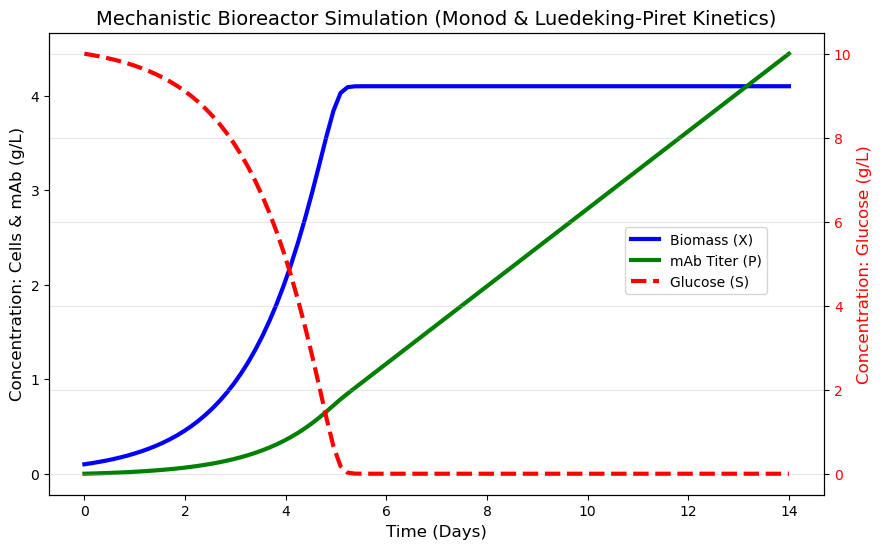

In [6]:
# ==========================================
# 5. VISUALIZE THE "WHITE BOX" MANIFOLD
# ==========================================
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot Biomass and Titer on the left Y-axis
ax1.plot(time_days, X_sim, 'b-', linewidth=3, label='Biomass (X)')
ax1.plot(time_days, P_sim, 'g-', linewidth=3, label='mAb Titer (P)')
ax1.set_xlabel('Time (Days)', fontsize=12)
ax1.set_ylabel('Concentration: Cells & mAb (g/L)', color='black', fontsize=12)
ax1.tick_params(axis='y', labelcolor='black')

# Plot Glucose on the right Y-axis (since it starts much higher)
ax2 = ax1.twinx()
ax2.plot(time_days, S_sim, 'r--', linewidth=3, label='Glucose (S)')
ax2.set_ylabel('Concentration: Glucose (g/L)', color='red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='red')

# Add titles and legends
plt.title('Mechanistic Bioreactor Simulation (Monod & Luedeking-Piret Kinetics)', fontsize=14)
fig.legend(loc="center right", bbox_to_anchor=(0.85, 0.5), fontsize=10)
plt.grid(alpha=0.3)
plt.show()